# Import and Set Up

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor

## Upload PKL Files

In [2]:
df_old = pd.read_pickle(r"2024-25 NBA Stats.pkl")
df_old

,Player Name,Age,TEAM,POS,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,BLK,TOV,Fantasy Points
Rank,,,,,,,,,,,,,,,,
1,Nikola Jokic,29,DEN,C,70,36.7,29.6,0.576,0.800,2.0,12.7,10.2,1.8,0.6,3.3,17.28
2,Victor Wembanyama,21,SAS,C,46,33.2,24.3,0.476,0.836,3.1,11.0,3.7,1.1,3.8,3.2,16.28
3,Shai Gilgeous-Alexander,26,OKC,PG,76,34.2,32.7,0.519,0.898,2.1,5.0,6.4,1.7,1.0,2.4,15.67
4,Giannis Antetokounmpo,30,MIL,PF,67,34.2,30.4,0.601,0.617,0.2,11.9,6.5,0.9,1.2,3.1,10.78
5,Anthony Davis,31,DAL,PF,51,33.5,24.7,0.516,0.775,0.7,11.6,3.5,1.2,2.2,2.2,10.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,Devin Carter,22,SAC,PG,36,11.0,3.8,0.370,0.591,0.5,2.1,1.1,0.6,0.1,0.5,-8.27
432,Olivier-Maxence Prosper,22,DAL,PF,52,11.2,3.9,0.402,0.645,0.2,2.4,0.8,0.5,0.1,0.3,-8.41
433,Dillon Jones,23,OKC,SF,54,10.2,2.5,0.383,0.607,0.3,2.2,1.1,0.3,0.1,0.5,-8.51


In [3]:
df_new = pd.read_pickle(r"Next Year Predicted Stats.pkl")
df_final = df_new.copy()
df_new

,Player Name,Age,TEAM,POS,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,BLK,TOV
0,Shai Gilgeous-Alexander,26,OKC,PG,76.0,34.30,34.30,0.5190,0.8970,2.10,5.00,6.45,1.7,1.0,2.4
1,Giannis Antetokounmpo,30,MIL,PF,67.0,34.30,30.25,0.6010,0.6185,0.20,11.55,6.50,0.9,1.2,3.1
2,Nikola Jokic,29,DEN,C,70.0,36.65,30.25,0.5760,0.8000,2.00,12.75,10.30,1.8,0.6,3.3
3,Luka Doncic,25,LAL,PG,50.0,35.40,27.90,0.4500,0.7810,3.50,8.20,7.75,1.8,0.4,3.5
4,Anthony Edwards,23,MIN,SG,79.0,36.25,27.10,0.4470,0.8360,3.85,5.75,4.50,1.2,0.6,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,Dillon Jones,23,OKC,SF,54.0,10.15,2.50,0.3815,0.6075,0.30,2.20,1.10,0.3,0.1,0.5
432,John Konchar,28,MEM,SG,46.0,12.05,2.35,0.4505,0.8745,0.50,3.30,0.90,0.7,0.3,0.3
433,Dwight Powell,33,DAL,C,55.0,10.00,2.05,0.6910,0.6495,0.00,2.10,1.00,0.3,0.4,0.3
434,Jericho Sims,26,MIL,C,53.0,11.85,1.80,0.6315,0.6145,0.00,3.70,0.60,0.2,0.4,0.6


## Define Target

In [4]:
features_x = df_old.drop(columns=["Fantasy Points"])
target_y = df_old[["Fantasy Points"]]

In [5]:
features_x = features_x.reset_index(drop=True)
features_x

,Player Name,Age,TEAM,POS,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,BLK,TOV
0,Nikola Jokic,29,DEN,C,70,36.7,29.6,0.576,0.800,2.0,12.7,10.2,1.8,0.6,3.3
1,Victor Wembanyama,21,SAS,C,46,33.2,24.3,0.476,0.836,3.1,11.0,3.7,1.1,3.8,3.2
2,Shai Gilgeous-Alexander,26,OKC,PG,76,34.2,32.7,0.519,0.898,2.1,5.0,6.4,1.7,1.0,2.4
3,Giannis Antetokounmpo,30,MIL,PF,67,34.2,30.4,0.601,0.617,0.2,11.9,6.5,0.9,1.2,3.1
4,Anthony Davis,31,DAL,PF,51,33.5,24.7,0.516,0.775,0.7,11.6,3.5,1.2,2.2,2.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,Devin Carter,22,SAC,PG,36,11.0,3.8,0.370,0.591,0.5,2.1,1.1,0.6,0.1,0.5
431,Olivier-Maxence Prosper,22,DAL,PF,52,11.2,3.9,0.402,0.645,0.2,2.4,0.8,0.5,0.1,0.3
432,Dillon Jones,23,OKC,SF,54,10.2,2.5,0.383,0.607,0.3,2.2,1.1,0.3,0.1,0.5
433,Trey Jemison,25,LAL,C,38,10.3,2.5,0.554,0.394,0.0,2.8,0.4,0.2,0.4,0.6


In [6]:
target_y

,Fantasy Points
Rank,
1,17.28
2,16.28
3,15.67
4,10.78
5,10.28
...,...
431,-8.27
432,-8.41
433,-8.51


# Feature Engineering

## One-Hot Encoding

In [7]:
columns_to_convert = ['Age', 'G', "MPG", "PTS", 
                      "FG%", "FT%", "3PT", "REB", 
                      "AST", "STL", "BLK", "TOV"]

for col in columns_to_convert:
    features_x[col] = pd.to_numeric(features_x[col], errors='coerce')
    
categorical_cols = features_x.select_dtypes(include=["object", "category"])
categorical_cols = categorical_cols.drop(columns=['Player Name'])
encoded_cols = []

for col in categorical_cols:
    encoded = pd.get_dummies(categorical_cols[col], prefix=col, dtype=int)
    encoded = encoded[sorted(encoded.columns)]

    if len(categorical_cols[col].unique()) == 2:
        encoded = encoded.iloc[:, 1:]

    encoded_cols.append(encoded)

encoded_features_x = pd.concat(encoded_cols, axis=1)
encoded_features_x = encoded_features_x.reset_index(drop=True)
encoded_features_x

,TEAM_ATL,TEAM_BKN,TEAM_BOS,TEAM_BRK,TEAM_CHI,TEAM_CHO,TEAM_CLE,TEAM_DAL,TEAM_DEN,TEAM_DET,...,TEAM_SAC,TEAM_SAS,TEAM_TOR,TEAM_UTA,TEAM_WAS,POS_C,POS_PF,POS_PG,POS_SF,POS_SG
0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0
431,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
432,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
433,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


## Scaling

In [8]:
features_x = features_x.select_dtypes(exclude=["object", "category"])

scaler = StandardScaler()
features_x_scaled = scaler.fit_transform(features_x)
features_x = pd.DataFrame(features_x_scaled, columns=features_x.columns, index=features_x.index)

features_x = pd.concat([features_x, encoded_features_x], axis=1)
features_x

,Age,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,...,TEAM_SAC,TEAM_SAS,TEAM_TOR,TEAM_UTA,TEAM_WAS,POS_C,POS_PF,POS_PG,POS_SF,POS_SG
0,0.668404,0.774998,1.817335,2.995243,1.471092,0.359737,0.814037,3.662242,4.187369,2.672267,...,0,0,0,0,0,1,0,0,0,0
1,-1.205928,-0.491791,1.356363,2.152519,0.162853,0.623390,2.042797,2.928842,0.650148,0.821675,...,0,1,0,0,0,1,0,0,0,0
2,-0.034470,1.091695,1.488069,3.488157,0.725396,1.077460,0.925743,0.340369,2.119455,2.407896,...,0,0,0,0,0,0,0,1,0,0
3,0.902695,0.616649,1.488069,3.122447,1.798152,-0.980501,-1.196660,3.317113,2.173874,0.292934,...,0,0,0,0,0,0,1,0,0,0
4,1.136987,-0.227876,1.395875,2.216121,0.686149,0.176644,-0.638133,3.187689,0.541311,1.086045,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,-0.971636,-1.019619,-1.567517,-1.107074,-1.223880,-1.170917,-0.861544,-0.910726,-0.764740,-0.500176,...,1,0,0,0,0,0,0,1,0,0
431,-0.971636,-0.175093,-1.541176,-1.091173,-0.805244,-0.775437,-1.196660,-0.781302,-0.927997,-0.764547,...,0,0,0,0,0,0,1,0,0,0
432,-0.737345,-0.069528,-1.672882,-1.313779,-1.053809,-1.053738,-1.084955,-0.867585,-0.764740,-1.293287,...,0,0,0,0,0,0,0,0,1,0
433,-0.268762,-0.914053,-1.659711,-1.313779,1.183280,-2.613687,-1.420071,-0.608737,-1.145672,-1.557657,...,0,0,0,0,0,1,0,0,0,0


# Machine Learning Model: GradientBoostingRegressor

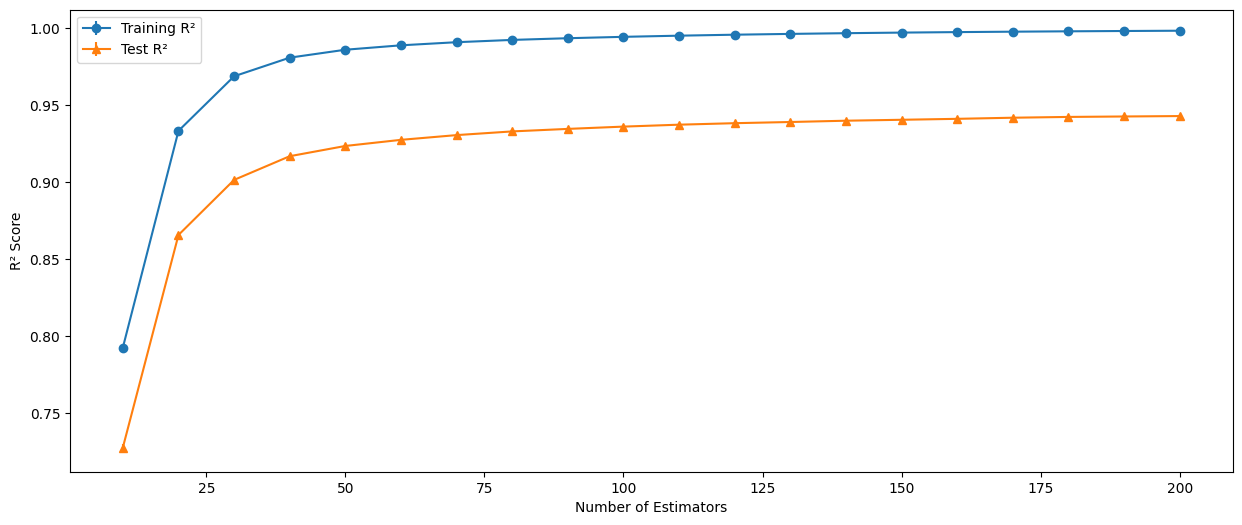

In [9]:
No_folds = 10
n_estimators_values = np.arange(10, 201, 10)  # 10 to 200 estimators

all_training = pd.DataFrame(index=range(No_folds))
all_test = pd.DataFrame(index=range(No_folds))

kf = KFold(n_splits=No_folds, shuffle=True, random_state=42)

for n_estimators_run in n_estimators_values:
    training_accuracy = []
    test_accuracy = []

    for train_index, test_index in kf.split(features_x):
        X_train, X_test = features_x.iloc[train_index], features_x.iloc[test_index]
        y_train, y_test = target_y.iloc[train_index], target_y.iloc[test_index]

        # Reshape y_train and y_test to 1D array using .ravel()
        y_train = y_train.values.ravel()
        y_test = y_test.values.ravel()

        gbm = GradientBoostingRegressor(n_estimators=n_estimators_run, random_state=42).fit(X_train, y_train)
        training_accuracy.append(gbm.score(X_train, y_train))
        test_accuracy.append(gbm.score(X_test, y_test))

    all_training[n_estimators_run] = training_accuracy
    all_test[n_estimators_run] = test_accuracy

plt.figure(figsize=(15, 6))
plt.xscale("linear")
plt.errorbar(
    n_estimators_values,
    all_training.mean(axis=0),
    yerr=all_training.var(axis=0),
    label="Training R²",
    marker="o",
)
plt.errorbar(
    n_estimators_values,
    all_test.mean(axis=0),
    yerr=all_test.var(axis=0),
    label="Test R²",
    marker="^",
)
plt.ylabel("R² Score")
plt.xlabel("Number of Estimators")
plt.legend()
plt.show()


## Run Model to New Dataset

In [10]:
df_new

,Player Name,Age,TEAM,POS,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,BLK,TOV
0,Shai Gilgeous-Alexander,26,OKC,PG,76.0,34.30,34.30,0.5190,0.8970,2.10,5.00,6.45,1.7,1.0,2.4
1,Giannis Antetokounmpo,30,MIL,PF,67.0,34.30,30.25,0.6010,0.6185,0.20,11.55,6.50,0.9,1.2,3.1
2,Nikola Jokic,29,DEN,C,70.0,36.65,30.25,0.5760,0.8000,2.00,12.75,10.30,1.8,0.6,3.3
3,Luka Doncic,25,LAL,PG,50.0,35.40,27.90,0.4500,0.7810,3.50,8.20,7.75,1.8,0.4,3.5
4,Anthony Edwards,23,MIN,SG,79.0,36.25,27.10,0.4470,0.8360,3.85,5.75,4.50,1.2,0.6,3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,Dillon Jones,23,OKC,SF,54.0,10.15,2.50,0.3815,0.6075,0.30,2.20,1.10,0.3,0.1,0.5
432,John Konchar,28,MEM,SG,46.0,12.05,2.35,0.4505,0.8745,0.50,3.30,0.90,0.7,0.3,0.3
433,Dwight Powell,33,DAL,C,55.0,10.00,2.05,0.6910,0.6495,0.00,2.10,1.00,0.3,0.4,0.3
434,Jericho Sims,26,MIL,C,53.0,11.85,1.80,0.6315,0.6145,0.00,3.70,0.60,0.2,0.4,0.6


### One-Hot Encode and Scale

In [11]:
columns_to_convert = ['Age', 'G', "MPG", "PTS", 
                      "FG%", "FT%", "3PT", "REB", 
                      "AST", "STL", "BLK", "TOV"]

for col in columns_to_convert:
    df_new[col] = pd.to_numeric(df_new[col], errors='coerce')
    
categorical_cols = df_new.select_dtypes(include=["object", "category"])
categorical_cols = categorical_cols.drop(columns=['Player Name'])
encoded_cols = []

for col in categorical_cols:
    encoded = pd.get_dummies(categorical_cols[col], prefix=col, dtype=int)
    encoded = encoded[sorted(encoded.columns)]

    if len(categorical_cols[col].unique()) == 2:
        encoded = encoded.iloc[:, 1:]

    encoded_cols.append(encoded)

encoded_df_new = pd.concat(encoded_cols, axis=1)
encoded_df_new = encoded_df_new.reset_index(drop=True)

df_new = df_new.select_dtypes(exclude=["object", "category"])

scaler = StandardScaler()
df_new_scaled = scaler.fit_transform(df_new)
df_new = pd.DataFrame(df_new_scaled, columns=df_new.columns, index=df_new.index)

df_new = pd.concat([df_new, encoded_df_new], axis=1)
df_new

,Age,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,...,TEAM_SAC,TEAM_SAS,TEAM_TOR,TEAM_UTA,TEAM_WAS,POS_C,POS_PF,POS_PG,POS_SF,POS_SG
0,-0.032797,1.091165,1.502743,3.741332,0.743678,1.097129,0.930928,0.338587,2.160979,2.478040,...,0,0,0,0,0,0,0,1,0,0
1,0.904861,0.619141,1.502743,3.097927,1.846684,-1.021654,-1.197348,3.170027,2.188330,0.304692,...,0,0,0,0,0,0,1,0,0,0
2,0.670447,0.776482,1.812469,3.097927,1.510402,0.359169,0.818914,3.688764,4.267005,2.749709,...,0,0,0,0,0,1,0,0,0,0
3,-0.267211,-0.272461,1.647721,2.724594,-0.184462,0.214620,2.499131,1.721886,2.872105,2.749709,...,0,0,0,0,0,0,0,1,0,0
4,-0.736040,1.248507,1.759750,2.597502,-0.224816,0.633051,2.891182,0.662798,1.094291,1.119698,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,-0.736040,-0.062672,-1.680187,-1.310584,-1.105876,-1.105340,-1.085333,-0.871800,-0.765577,-1.325319,...,0,0,0,0,0,0,0,0,1,0
432,0.436032,-0.482249,-1.429770,-1.334414,-0.177736,0.925953,-0.861304,-0.396291,-0.874981,-0.238645,...,0,0,0,0,0,0,0,0,0,1
433,1.608105,-0.010225,-1.699957,-1.382073,3.057301,-0.785811,-1.421377,-0.915028,-0.820279,-1.325319,...,0,0,0,0,0,1,0,0,0,0
434,-0.032797,-0.115119,-1.456130,-1.421790,2.256949,-1.052085,-1.421377,-0.223378,-1.039087,-1.596987,...,0,0,0,0,0,1,0,0,0,0


### Running the Model

In [ ]:
final_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
final_model.fit(features_x, target_y)

features = list(features_x.columns)

for feature in features:
    if feature in df_new.columns:
        df_new[feature] = pd.to_numeric(df_new[feature], errors='coerce')

df_new = df_new.fillna(0)
df_new["Fantasy Points"] = final_model.predict(df_new[features])
df_final['Fantasy Points'] = df_new['Fantasy Points']
df_final['Fantasy Points'] = df_final['Fantasy Points'].round(2)
df_final = df_final.sort_values(by='Fantasy Points', ascending=False).reset_index(drop=True)

df_final

C:\Users\julia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


,Player Name,Age,TEAM,POS,G,MPG,PTS,FG%,FT%,3PT,REB,AST,STL,BLK,TOV,Fantasy Points
0,Nikola Jokic,29,DEN,C,70.0,36.65,30.25,0.5760,0.8000,2.0,12.75,10.30,1.8,0.6,3.3,17.19
1,Shai Gilgeous-Alexander,26,OKC,PG,76.0,34.30,34.30,0.5190,0.8970,2.1,5.00,6.45,1.7,1.0,2.4,15.28
2,Victor Wembanyama,21,SAS,C,46.0,33.25,24.15,0.4770,0.8360,3.1,11.00,3.70,1.1,3.0,3.3,15.23
3,Giannis Antetokounmpo,30,MIL,PF,67.0,34.30,30.25,0.6010,0.6185,0.2,11.55,6.50,0.9,1.2,3.1,10.68
4,Anthony Davis,31,DAL,PF,51.0,33.50,24.50,0.5155,0.7745,0.7,11.55,3.50,1.2,2.3,2.2,10.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,Devin Carter,22,SAC,PG,36.0,11.00,3.80,0.3700,0.5900,0.5,2.10,1.10,0.6,0.1,0.5,-8.07
432,Jett Howard,21,ORL,SF,60.0,11.60,4.50,0.3750,0.6970,0.9,1.20,0.70,0.2,0.2,0.6,-8.07
433,Trey Jemison,25,LAL,C,38.0,10.30,2.50,0.5555,0.4045,0.0,2.80,0.40,0.2,0.4,0.6,-8.24
434,Dillon Jones,23,OKC,SF,54.0,10.15,2.50,0.3815,0.6075,0.3,2.20,1.10,0.3,0.1,0.5,-8.25


# Draft Simulation

In [13]:
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd

class FantasyDraftApp(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Fantasy Draft Simulator")
        self.configure(bg="#f0f4f8")
        self.geometry("1000x800")  # Increased overall window size
        self.df_temp = None
        self.numerical_cols = []
        self.team_names = []
        self.user_team = None
        self.team_stats_sum = {}
        self.team_draft_count = {}
        self.drafted_players = {}
        self.rounds = 0
        self.pick = 0
        self.teams = 0
        self.current_round = 0
        self.draft_order = []
        self.current_pick_index = 0
        self.player_entry = None
        self.info_text = None
        self.roster_text = None
        self.available_players_listbox = None
        self.draft_complete = False
        self.start_page()

    def start_page(self):
        self.clear_frame()
        frame = tk.Frame(self, bg="#f0f4f8")
        frame.pack(expand=True, padx=40, pady=40)  # Increased padding around the main frame

        title_label = tk.Label(frame, text="Fantasy Draft Setup", font=("Helvetica", 36, "bold"), bg="#f0f4f8") # Larger title
        title_label.pack(pady=40)

        setup_frame = tk.Frame(frame, bg="#e0e8f0", padx=30, pady=30) # Slightly darker background for the setup area
        setup_frame.pack(pady=20)

        tk.Label(setup_frame, text="Rounds:", font=("Helvetica", 18), bg="#e0e8f0").grid(row=0, column=0, padx=10, pady=10, sticky="w")
        self.rounds_var = tk.IntVar()
        tk.Entry(setup_frame, textvariable=self.rounds_var, font=("Helvetica", 18), width=5).grid(row=0, column=1, padx=10, pady=10)

        tk.Label(setup_frame, text="Your Pick:", font=("Helvetica", 18), bg="#e0e8f0").grid(row=1, column=0, padx=10, pady=10, sticky="w")
        self.pick_var = tk.IntVar()
        tk.Entry(setup_frame, textvariable=self.pick_var, font=("Helvetica", 18), width=5).grid(row=1, column=1, padx=10, pady=10)

        tk.Label(setup_frame, text="Total Teams:", font=("Helvetica", 18), bg="#e0e8f0").grid(row=2, column=0, padx=10, pady=10, sticky="w")
        self.teams_var = tk.IntVar()
        tk.Entry(setup_frame, textvariable=self.teams_var, font=("Helvetica", 18), width=5).grid(row=2, column=1, padx=10, pady=10)

        start_button = tk.Button(frame, text="Start Draft Setup", command=self.setup_team_names, font=("Helvetica", 20, "bold"), bg="#4da6ff", fg="white", padx=20, pady=10) # Larger button
        start_button.pack(pady=40)

    def setup_team_names(self):
        self.rounds = self.rounds_var.get()
        self.pick = self.pick_var.get()
        self.teams = self.teams_var.get()

        if not all([self.rounds, self.pick, self.teams]) or not (1 <= self.pick <= self.teams):
            messagebox.showerror("Error", "Please enter valid draft parameters and ensure 'df_final' DataFrame exists.")
            return

        self.clear_frame()
        frame = tk.Frame(self, bg="#f0f4f8")
        frame.pack(expand=True, padx=20, pady=20)

        tk.Label(frame, text="Enter Team Names", font=("Helvetica", 20, "bold"), bg="#f0f4f8").pack(pady=20)
        self.team_name_entries = []
        for i in range(self.teams):
            label = tk.Label(frame, text=f"Team {i + 1}:", font=("Helvetica", 14), bg="#f0f4f8")
            entry = tk.Entry(frame, font=("Helvetica", 14), width=30)
            label.pack(pady=5)
            entry.pack(pady=5)
            self.team_name_entries.append(entry)

        tk.Button(frame, text="Start Draft", command=self.start_draft, font=("Helvetica", 14), bg="#4da6ff", fg="white").pack(pady=20)

    def start_draft(self):
        self.team_names = [entry.get() if entry.get() else f"Team {i + 1}" for i, entry in enumerate(self.team_name_entries)]
        self.user_team = self.team_names[self.pick - 1]
        self.df_temp = globals()['df_final'].copy()  # Initialize df_temp FIRST
        numerical_cols = self.get_numerical_cols()  # Get numerical columns AFTER df_temp is initialized
        self.team_stats_sum = {team: pd.Series(0.0, index=numerical_cols) for team in self.team_names}
        self.team_draft_count = {team: 0 for team in self.team_names}
        self.drafted_players = {team: [] for team in self.team_names}
        self.current_round = 0
        self.current_pick_index = 0
        self.draft_order = self.generate_draft_order()
        self.draft_complete = False
        self.create_draft_page()

    def get_numerical_cols(self):
        if not self.numerical_cols and 'df_final' in globals() and isinstance(globals()['df_final'], pd.DataFrame):
            self.numerical_cols = [col for col in globals()['df_final'].select_dtypes(include=['number']).columns if col not in ['Age', 'G', 'MPG']]
            if 'Player Name' in self.numerical_cols:
                self.numerical_cols.remove('Player Name')
            if "TEAM" in self.numerical_cols:
                self.numerical_cols.remove("TEAM")
            if "POS" in self.numerical_cols:
                self.numerical_cols.remove("POS")
            if 'Fantasy Points' in self.numerical_cols:
                self.numerical_cols.remove('Fantasy Points')
            elif 'Fantasy Points' in self.df_temp.columns and 'Fantasy Points' not in self.numerical_cols:
                self.numerical_cols.append('Fantasy Points')
            return self.numerical_cols
        elif self.numerical_cols and 'Fantasy Points' in self.numerical_cols and self.numerical_cols[-1] != 'Fantasy Points':
            self.numerical_cols.remove('Fantasy Points')
            self.numerical_cols.append('Fantasy Points')
        return self.numerical_cols

    def generate_draft_order(self):
        order = []
        for r in range(self.rounds):
            if r % 2 == 0:
                order.extend(self.team_names)
            else:
                order.extend(reversed(self.team_names))
        return order

    def create_draft_page(self):
        self.clear_frame()
        if self.draft_complete:
            self.show_final_summary()
            return

        self.title(f"Round {self.current_round + 1} - Pick {self.current_pick_index % self.teams + 1}")
        main_frame = tk.Frame(self, bg="#f0f4f8")
        main_frame.pack(fill=tk.BOTH, expand=True, padx=20, pady=20)

        # Top 20 Fantasy (Scrollable - Adjusted Padding)
        fantasy_frame = tk.Frame(main_frame, bg="#e0f2f7", padx=10, pady=5) # Added padx and pady
        fantasy_frame.pack(fill=tk.X, pady=10)
        tk.Label(fantasy_frame, text="Top 20 Fantasy Players:", font=("Helvetica", 14, "bold"), bg="#e0f2f7").pack()
        fantasy_scrollbar = tk.Scrollbar(fantasy_frame)
        self.fantasy_text = tk.Text(fantasy_frame, height=10, font=("Helvetica", 12), bg="#e0f2f7", yscrollcommand=fantasy_scrollbar.set)
        self.fantasy_text.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        fantasy_scrollbar.config(command=self.fantasy_text.yview)
        fantasy_scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        self.update_top_20_fantasy_display()

        # Top 5 by Stat and Suggestion Frame
        top_suggestion_frame = tk.Frame(main_frame, bg="#f0f4f8", padx=10, pady=5)
        top_suggestion_frame.pack(fill=tk.X, pady=10)

        # Top 5 by Stat (Non-Scrollable - Adjusted Padding)
        top_stats_frame = tk.Frame(top_suggestion_frame, bg="#f0f4f8", padx=10, pady=5) # Added padx and pady
        top_stats_frame.pack(side=tk.LEFT, fill=tk.X, expand=True)
        tk.Label(top_stats_frame, text="Top 5 by Stat:", font=("Helvetica", 14, "bold"), bg="#f0f4f8").pack()
        self.top_stats_text = tk.Text(top_stats_frame, height=8, font=("Helvetica", 12), bg="#f0f4f8")
        self.top_stats_text.pack(fill=tk.X)
        self.top_stats_text.config(state=tk.DISABLED)
        self.update_top_5_stats_display()

        # Suggestion Area
        suggestion_frame = tk.Frame(top_suggestion_frame, bg="#e0f7de", padx=10, pady=5)
        suggestion_frame.pack(side=tk.RIGHT, fill=tk.X, expand=True, padx=10)
        tk.Label(suggestion_frame, text="Top 5 Suggested Picks:", font=("Helvetica", 14, "bold"), bg="#e0f7de").pack()
        self.suggestion_text = tk.Text(suggestion_frame, height=8, font=("Helvetica", 12), bg="#e0f7de")
        self.suggestion_text.pack(fill=tk.X)
        self.suggestion_text.config(state=tk.DISABLED)
        self.update_suggestion_display()

        # Available Players List (Smaller height - Adjusted Padding)
        available_frame = tk.Frame(main_frame, bg="#f0f4f8", padx=10, pady=5) # Added padx and pady
        available_frame.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        tk.Label(available_frame, text="Available Players:", font=("Helvetica", 14, "bold"), bg="#f0f4f8").pack(pady=5)
        scrollbar = tk.Scrollbar(available_frame)
        self.available_players_listbox = tk.Listbox(available_frame, yscrollcommand=scrollbar.set, font=("Helvetica", 12), height=5)
        self.available_players_listbox.pack(side=tk.LEFT, fill=tk.BOTH, expand=True)
        scrollbar.config(command=self.available_players_listbox.yview)
        scrollbar.pack(side=tk.RIGHT, fill=tk.Y)
        self.populate_available_players()

        # Player Selection (No change needed)
        select_frame = tk.Frame(main_frame, bg="#f0f4f8")
        select_frame.pack(pady=10)
        current_team = self.draft_order[self.current_round * self.teams + (self.current_pick_index % self.teams)]
        tk.Label(select_frame, text=f"{current_team}'s Pick:", font=("Helvetica", 14, "bold"), bg="#f0f4f8").pack(side=tk.LEFT)
        self.player_entry = tk.Entry(select_frame, font=("Helvetica", 12), width=30)
        self.player_entry.pack(side=tk.LEFT, padx=5)
        tk.Button(select_frame, text="Draft Player", command=self.draft_player, font=("Helvetica", 12), bg="#4da6ff", fg="white").pack(side=tk.LEFT, padx=5)

        # Rosters Display (No change needed)
        roster_frame = tk.Frame(main_frame, bg="#e0f2f7")
        roster_frame.pack(fill=tk.X, pady=10)
        tk.Label(roster_frame, text="Team Rosters:", font=("Helvetica", 14, "bold"), bg="#e0f2f7").pack()
        self.roster_text = tk.Text(roster_frame, height=5, font=("Helvetica", 12), bg="#e0f2f7")
        self.roster_text.pack(fill=tk.X)
        self.roster_text.config(state=tk.DISABLED)
        self.update_rosters_display()

    def update_suggestion_display(self):
        self.suggestion_text.config(state=tk.NORMAL)
        self.suggestion_text.delete(1.0, tk.END)
        bold_font = ("Helvetica", 12, "bold")
        normal_font = ("Helvetica", 12)

        current_team_name = self.draft_order[self.current_round * self.teams + (self.current_pick_index % self.teams)]
        if current_team_name == self.user_team and not self.df_temp.empty and self.get_numerical_cols():
            # Suggest top 5 players with the highest average of normalized stats
            temp_df = self.df_temp.copy()
            for col in self.get_numerical_cols():
                if temp_df[col].max() > temp_df[col].min():
                    temp_df[f'{col}_normalized'] = (temp_df[col] - temp_df[col].min()) / (temp_df[col].max() - temp_df[col].min())
                else:
                    temp_df[f'{col}_normalized'] = 0.5 # Avoid division by zero

            if [f'{col}_normalized' for col in self.get_numerical_cols()] :
                temp_df['suggestion_score'] = temp_df[[f'{col}_normalized' for col in self.get_numerical_cols()]].mean(axis=1)
                top_suggestions = temp_df.nlargest(5, 'suggestion_score')['Player Name'].tolist()
                if top_suggestions:
                    self.suggestion_text.insert(tk.END, f"Top 5 Suggested Picks:\n", bold_font)
                    for i, player in enumerate(top_suggestions):
                        self.suggestion_text.insert(tk.END, f"{i+1}. {player}\n", normal_font)
                else:
                    self.suggestion_text.insert(tk.END, "No suitable players to suggest.\n", normal_font)
            else:
                self.suggestion_text.insert(tk.END, "No statistical data to suggest.\n", normal_font)
        elif not self.df_temp.empty:
            # If not the user's turn, just show the top 5 available players by fantasy points
            if 'Fantasy Points' in self.df_temp.columns:
                top_available = self.df_temp.nlargest(5, 'Fantasy Points')['Player Name'].tolist()
                if top_available:
                    self.suggestion_text.insert(tk.END, f"Top 5 Available Players:\n", bold_font)
                    for i, player in enumerate(top_available):
                        self.suggestion_text.insert(tk.END, f"{i+1}. {player}\n", normal_font)
                else:
                    self.suggestion_text.insert(tk.END, "No top available players.\n", normal_font)
            else:
                self.suggestion_text.insert(tk.END, "Fantasy data unavailable for suggestion.\n", normal_font)
        else:
            self.suggestion_text.insert(tk.END, "No players available for suggestion.\n", normal_font)

        self.suggestion_text.config(state=tk.DISABLED)

    def update_top_20_fantasy_display(self):
        self.fantasy_text.config(state=tk.NORMAL)
        self.fantasy_text.delete(1.0, tk.END)
        bold_font = ("Helvetica", 12, "bold")
        normal_font = ("Helvetica", 12)

        if 'df_temp' in self.__dict__ and isinstance(self.df_temp, pd.DataFrame) and 'Fantasy Points' in self.df_temp.columns:
            top_fantasy = self.df_temp.nlargest(20, 'Fantasy Points')[['Player Name', 'Fantasy Points']]
            self.fantasy_text.insert(tk.END, "Top 20 Fantasy Players:\n", bold_font)
            for p, fp in top_fantasy.values:
                self.fantasy_text.insert(tk.END, f"{p} ({fp:.2f})\n", normal_font)
            self.fantasy_text.insert(tk.END, "\n")
        else:
            self.fantasy_text.insert(tk.END, "Fantasy Points data not available in df_temp.\n\n", normal_font)
        self.fantasy_text.config(state=tk.DISABLED)

    def update_top_5_stats_display(self):
        self.top_stats_text.config(state=tk.NORMAL)
        self.top_stats_text.delete(1.0, tk.END)
        bold_font = ("Helvetica", 12, "bold")
        normal_font = ("Helvetica", 12)

        for col in self.get_numerical_cols():
            if col == 'Fantasy Points':
                continue
            if col in self.df_temp.columns:
                top_5 = self.df_temp.nlargest(5, col)[['Player Name', col]]
                if not top_5.empty:
                    self.top_stats_text.insert(tk.END, f"Top 5 {col}:\n", bold_font)
                    for p, v in top_5.values:
                        self.top_stats_text.insert(tk.END, f"{p} ({v:.2f})\n", normal_font)
                    self.top_stats_text.insert(tk.END, "\n\n") # Add more space between stats
            else:
                self.top_stats_text.insert(tk.END, f"{col} data not available.\n\n", normal_font)
        self.top_stats_text.config(state=tk.DISABLED)

    def populate_available_players(self):
        self.available_players_listbox.delete(0, tk.END)
        for player in self.df_temp['Player Name'].tolist():
            self.available_players_listbox.insert(tk.END, player)

    def update_info(self):
        self.info_text.config(state=tk.NORMAL)
        self.info_text.delete(1.0, tk.END)
        bold_font = ("Helvetica", 12, "bold")
        normal_font = ("Helvetica", 12)

        if 'df_final' in globals() and isinstance(globals()['df_final'], pd.DataFrame) and 'Fantasy Points' in globals()['df_final'].columns:
            top_fantasy = globals()['df_final'].nlargest(20, 'Fantasy Points')[['Player Name', 'Fantasy Points']]
            self.info_text.insert(tk.END, "Top 20 Fantasy:\n", bold_font)
            for p, fp in top_fantasy.values:
                self.info_text.insert(tk.END, f"{p} ({fp:.2f})\n", normal_font)
            self.info_text.insert(tk.END, "\n")
        else:
            self.info_text.insert(tk.END, "Fantasy Points data not available in df_final.\n\n", normal_font)

        self.info_text.insert(tk.END, "Top 5 by Stat:\n", bold_font)
        for col in self.get_numerical_cols():
            if col == 'Fantasy Points':
                continue
            if col in self.df_temp.columns:
                top_5 = self.df_temp.nlargest(5, col)[['Player Name', col]]
                if not top_5.empty:
                    self.info_text.insert(tk.END, f"\nTop 5 {col}:\n", bold_font)
                    for p, v in top_5.values:
                        self.info_text.insert(tk.END, f"{p} ({v:.2f})\n", normal_font)
                    self.info_text.insert(tk.END, "\n")
            else:
                self.info_text.insert(tk.END, f"\n{col} data not available.\n\n", normal_font)
        self.info_text.config(state=tk.DISABLED)

    def draft_player(self):
        selected_player = self.player_entry.get().strip()
        if not selected_player and self.available_players_listbox.curselection():
            selected_player = self.available_players_listbox.get(self.available_players_listbox.curselection()[0])

        current_team = self.draft_order[self.current_round * self.teams + (self.current_pick_index % self.teams)]

        if selected_player and selected_player in self.df_temp['Player Name'].values:
            try:
                player_stats = self.df_temp[self.df_temp['Player Name'] == selected_player][self.get_numerical_cols()].iloc[0]
                self.team_stats_sum[current_team] = self.team_stats_sum[current_team].add(player_stats, fill_value=0)
                self.team_draft_count[current_team] += 1
                self.drafted_players[current_team].append(selected_player)
                self.df_temp = self.df_temp[self.df_temp['Player Name'] != selected_player]
                self.player_entry.delete(0, tk.END)
                self.current_pick_index += 1

                self.update_top_20_fantasy_display() # Update Top 20 after each pick
                self.update_top_5_stats_display()
                self.update_suggestion_display() # Update suggestion

                self.populate_available_players() # Update available players list
                self.update_rosters_display()

                if self.current_pick_index % self.teams == 0:
                    self.show_round_summary()
                elif self.current_pick_index < self.rounds * self.teams:
                    self.create_draft_page()
                else:
                    self.draft_complete = True
                    self.show_final_summary()

            except KeyError as e:
                messagebox.showerror("Error", f"KeyError: {e}. Ensure your CSV has the correct column names.")
        else:
            messagebox.showerror("Error", "Invalid player name.")


    def update_rosters_display(self):
        self.roster_text.config(state=tk.NORMAL)
        self.roster_text.delete(1.0, tk.END)
        for team, players in self.drafted_players.items():
            self.roster_text.insert(tk.END, f"{team}: {', '.join(players)}\n")
        self.roster_text.config(state=tk.DISABLED)

    def show_round_summary(self):
        summary_window = tk.Toplevel(self)
        summary_window.title(f"End of Round {self.current_round + 1}")
        summary_frame = tk.Frame(summary_window, bg="#f0f4f8", padx=20, pady=20)
        summary_frame.pack(fill=tk.BOTH, expand=True)

        tk.Label(summary_frame, text=f"--- End of Round {self.current_round + 1} Average Stats ---",
                 font=("Helvetica", 16, "bold"), bg="#f0f4f8").pack(pady=10)

        tree = ttk.Treeview(summary_frame, columns=["Team"] + self.get_numerical_cols(), show="headings")
        tree.heading("Team", text="Team Name")
        tree.column("Team", width=150)
        for col in self.get_numerical_cols():
            tree.heading(col, text=col)
            tree.column(col, width=80)

        for team in self.team_names:
            if self.team_draft_count[team] > 0:
                avg_stats = (self.team_stats_sum[team] / self.team_draft_count[team]).round(2)
                values = [team] + [f"{avg:.2f}" for avg in avg_stats.values]
                tree.insert("", "end", values=values)
            else:
                values = [team] + ["0.00"] * len(self.get_numerical_cols())
                tree.insert("", "end", values=values)

        tree.pack(pady=10, fill=tk.X)

        next_round_button = tk.Button(summary_frame, text="Next Round", command=self.next_round,
                                      font=("Helvetica", 14), bg="#4da6ff", fg="white")
        next_round_button.pack(pady=10)

    def next_round(self):
        self.current_round += 1
        if self.current_round < self.rounds:
            self.create_draft_page()
        else:
            self.draft_complete = True
            self.show_final_summary()

    def show_final_summary(self):
        self.clear_frame()
        final_frame = tk.Frame(self, bg="#f0f4f8", padx=20, pady=20)
        final_frame.pack(fill=tk.BOTH, expand=True)

        tk.Label(final_frame, text="--- Final Draft Summary ---",
                 font=("Helvetica", 20, "bold"), bg="#f0f4f8").pack(pady=10)

        final_tree = ttk.Treeview(final_frame, columns=["Team"] + self.get_numerical_cols(), show="headings")
        final_tree.heading("Team", text="Team Name")
        final_tree.column("Team", width=150)
        for col in self.get_numerical_cols():
            final_tree.heading(col, text=col)
            final_tree.column(col, width=80)

        final_stats = {}
        for team in self.team_names:
            if self.team_draft_count[team] > 0:
                final_avg_stats = (self.team_stats_sum[team] / self.team_draft_count[team]).round(2)
                final_stats[team] = final_avg_stats
                values = [team] + [f"{avg:.2f}" for avg in final_avg_stats.values]
                final_tree.insert("", "end", values=values)
            else:
                final_stats[team] = pd.Series([0.0] * len(self.get_numerical_cols()), index=self.get_numerical_cols())
                values = [team] + ["0.00"] * len(self.get_numerical_cols())
                final_tree.insert("", "end", values=values)

        # Calculate and display user's rank
        if self.user_team in final_stats and self.team_names:
            user_final_stats = final_stats[self.user_team]
            rank_values = ["Your Rank"]
            for col in self.get_numerical_cols():
                stat_values = {team: final_stats[team][col] for team in self.team_names}
                sorted_ranks = sorted(stat_values, key=stat_values.get, reverse=True)
                try:
                    rank = sorted_ranks.index(self.user_team) + 1
                    rank_values.append(int(rank))
                except ValueError:
                    rank_values.append(0) # Handle cases where user has 0 in a stat

            final_tree.insert("", "end", values=rank_values, tags=("rank",))
            final_tree.tag_configure("rank", font=("Helvetica", 12, "bold"))

        final_tree.pack(pady=10, fill=tk.X)

        tk.Label(final_frame, text="--- Final Team Rosters ---",
                 font=("Helvetica", 16, "bold"), bg="#f0f4f8").pack(pady=10)
        roster_final_text = tk.Text(final_frame, height=10, font=("Helvetica", 12), bg="#e6f7ff")
        for team, players in self.drafted_players.items():
            roster_final_text.insert(tk.END, f"{team}: {', '.join(players)}\n")
        roster_final_text.config(state=tk.DISABLED)
        roster_final_text.pack(fill=tk.X, pady=10)

        new_draft_button = tk.Button(final_frame, text="New Draft", command=self.start_page,
                                      font=("Helvetica", 14), bg="#4da6ff", fg="white")
        new_draft_button.pack(pady=20)

    def clear_frame(self):
        for w in self.winfo_children():
            w.destroy()

if __name__ == "__main__":
    app = FantasyDraftApp()
    app.mainloop()  